# Nutrient Comparison: Calculated vs Claimed
MAE, MAPE and correlation (r) per nutrient per model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "Gemini Flash Lite": "../data/gemini_flash_lite_recipes_calculated.csv",
    "Gemini Flash":      "../data/gemini_flash_recipes_calculated.csv",
    "Grok 3 Fast":       "../data/grok_fast_recipes_calculated.csv",
    "Grok 4 Fast":       "../data/grok4_fast_recipes_calculated.csv",
    "GPT-5.4 Nano":      "../data/gpt54_nano_recipes_calculated.csv",
    "GPT-5.4 Mini":      "../data/gpt54_mini_recipes_calculated.csv",
}

# Tuples are (label, calculated col, claimed col, unit). Sodium claimed is None
# because it's derived from claimed_salt_g: Na_mg = salt_g / 2.5 * 1000.
nutrients = [
    ("Energy",  "calculated_calories.quantity", "claimed_energy_kcal", "kcal"),
    ("Protein", "calculated_protein",           "claimed_protein_g",   "g"),
    ("Fat",     "calculated_fat",               "claimed_fat_g",       "g"),
    ("Carbs",   "calculated_carbohydrate",      "claimed_carbs_g",     "g"),
    ("Sugar",   "calculated_sugar_total",       "claimed_sugar_g",     "g"),
    ("Fibre",   "calculated_dietary_fibre",     "claimed_fiber_g",     "g"),
    ("Sodium",  "calculated_sodium_(na)",       None,                  "mg"),
]

models = list(files.keys())
print("Files loaded:", models)

Files loaded: ['Gemini Flash Lite', 'Gemini Flash', 'Grok 3 Fast', 'Grok 4 Fast', 'GPT-5.4 Nano', 'GPT-5.4 Mini']


## 1. MAE, MAPE and r — table per nutrient

## 2. Article-style table: Mean Accuracy, MAPE and R² per model

In [2]:
article_nutrients = [
    ("Energy",        "calculated_calories.quantity", "claimed_energy_kcal", "kcal"),
    ("Protein",       "calculated_protein",           "claimed_protein_g",   "g"),
    ("Carbohydrates", "calculated_carbohydrate",      "claimed_carbs_g",     "g"),
    ("Fat",           "calculated_fat",               "claimed_fat_g",       "g"),
    ("Sugar",         "calculated_sugar_total",       "claimed_sugar_g",     "g"),
    ("Fibre",         "calculated_dietary_fibre",     "claimed_fiber_g",     "g"),
    ("Sodium",        "calculated_sodium_(na)",       None,                  "mg"),
]

article_rows = []
for model, path in files.items():
    df = pd.read_csv(path)
    w  = df["total_recipe_weight_g"].replace(0, np.nan)

    for label, calc_col, claim_col, unit in article_nutrients:
        # y = pipeline-calculated (ground truth), y_hat = LLM-claimed.
        y = df[calc_col] / w * 100
        if claim_col is None:
            y_hat = (df["claimed_salt_g"] / 2.5 * 1000) / w * 100
        else:
            y_hat = df[claim_col] / w * 100

        mask = y.notna() & y_hat.notna() & (y > 0) & (y_hat > 0)
        y_m, yh_m = y[mask], y_hat[mask]

        # Accuracy as defined in Kruschwitz et al.:
        # acc_i = max(0, 1 - |y_hat - y| / y), then averaged across recipes × 100.
        acc_per_recipe = np.maximum(0, 1 - (yh_m - y_m).abs() / y_m)
        mean_acc = acc_per_recipe.mean() * 100

        mape = ((yh_m - y_m).abs() / y_m).mean() * 100
        r2   = y_m.corr(yh_m) ** 2

        article_rows.append({
            "Model":             model,
            "Nutrient":          f"{label} ({unit}/100g)",
            "Mean Accuracy (%)": round(mean_acc, 1),
            "MAPE (%)":          round(mape, 1),
            "R²":                round(r2, 3),
        })

article_df = pd.DataFrame(article_rows)

for model in models:
    sub = article_df[article_df["Model"] == model][["Nutrient", "Mean Accuracy (%)", "MAPE (%)", "R²"]]
    print(f"\n{'─'*58}")
    print(f"  {model}")
    print(f"{'─'*58}")
    display(sub.set_index("Nutrient"))


──────────────────────────────────────────────────────────
  Gemini Flash Lite
──────────────────────────────────────────────────────────


,Mean Accuracy (%),MAPE (%),R²
Nutrient,,,
Energy (kcal/100g),66.5,38.1,0.457
Protein (g/100g),71.2,34.6,0.328
Carbohydrates (g/100g),48.5,104.7,0.473
Fat (g/100g),62.4,46.1,0.441
Sugar (g/100g),50.3,67.7,0.611
Fibre (g/100g),60.5,48.5,0.434
Sodium (mg/100g),48.2,147.7,0.054



──────────────────────────────────────────────────────────
  Gemini Flash
──────────────────────────────────────────────────────────


,Mean Accuracy (%),MAPE (%),R²
Nutrient,,,
Energy (kcal/100g),87.0,13.6,0.867
Protein (g/100g),84.6,16.2,0.621
Carbohydrates (g/100g),71.0,48.8,0.881
Fat (g/100g),78.1,23.1,0.797
Sugar (g/100g),73.8,27.4,0.950
Fibre (g/100g),73.2,37.1,0.744
Sodium (mg/100g),45.3,195.3,0.056



──────────────────────────────────────────────────────────
  Grok 3 Fast
──────────────────────────────────────────────────────────


...

,Mean Accuracy (%),MAPE (%),R²
Nutrient,,,
Energy (kcal/100g),73.2,27.2,0.851
Protein (g/100g),80.0,21.0,0.581
Carbohydrates (g/100g),57.7,55.4,0.838
Fat (g/100g),66.4,36.7,0.822
Sugar (g/100g),70.5,30.3,0.907
Fibre (g/100g),72.6,29.0,0.822
Sodium (mg/100g),48.9,117.4,0.147



──────────────────────────────────────────────────────────
  GPT-5.4 Nano
──────────────────────────────────────────────────────────


,Mean Accuracy (%),MAPE (%),R²
Nutrient,,,
Energy (kcal/100g),72.7,28.2,0.690
Protein (g/100g),67.5,36.5,0.159
Carbohydrates (g/100g),57.7,75.1,0.675
Fat (g/100g),66.0,38.1,0.686
Sugar (g/100g),61.0,40.9,0.786
Fibre (g/100g),63.1,52.0,0.591
Sodium (mg/100g),51.4,90.8,0.067



──────────────────────────────────────────────────────────
  GPT-5.4 Mini
──────────────────────────────────────────────────────────


,Mean Accuracy (%),MAPE (%),R²
Nutrient,,,
Energy (kcal/100g),81.1,19.3,0.845
Protein (g/100g),79.0,21.1,0.572
Carbohydrates (g/100g),76.6,51.3,0.830
Fat (g/100g),74.2,26.5,0.834
Sugar (g/100g),70.0,31.3,0.926
Fibre (g/100g),64.1,48.7,0.735
Sodium (mg/100g),60.0,62.1,0.025


In [3]:
rows = []
for model, path in files.items():
    df = pd.read_csv(path)
    w  = df["total_recipe_weight_g"].replace(0, np.nan)

    for label, calc_col, claim_col, unit in nutrients:
        calc = df[calc_col] / w * 100
        if claim_col is None:
            claim = (df["claimed_salt_g"] / 2.5 * 1000) / w * 100
        else:
            claim = df[claim_col] / w * 100

        mask = calc.notna() & claim.notna() & (claim > 0)
        c, cl = calc[mask], claim[mask]

        mae  = (c - cl).abs().mean()
        mape = ((c - cl).abs() / cl).mean() * 100
        r    = c.corr(cl)

        rows.append({
            "Model":    model,
            "Nutrient": f"{label} ({unit}/100g)",
            "MAE":      round(mae, 2),
            "MAPE (%)": round(mape, 1),
            "r":        round(r, 2),
        })

results_df = pd.DataFrame(rows)
display(results_df)

,Model,Nutrient,MAE,MAPE (%),r
0,Gemini Flash Lite,Energy (kcal/100g),66.59,35.9,0.68
1,Gemini Flash Lite,Protein (g/100g),2.37,40.3,0.57
2,Gemini Flash Lite,Fat (g/100g),3.41,44.3,0.66
3,Gemini Flash Lite,Carbs (g/100g),9.77,47.0,0.69
4,Gemini Flash Lite,Sugar (g/100g),3.65,53.6,0.78
5,Gemini Flash Lite,Fibre (g/100g),1.14,69.6,0.66
6,Gemini Flash Lite,Sodium (mg/100g),111.20,113.6,0.23
7,Gemini Flash,Energy (kcal/100g),17.82,13.6,0.93
8,Gemini Flash,Protein (g/100g),1.06,15.8,0.79
9,Gemini Flash,Fat (g/100g),1.26,34.4,0.89


## 2. Summary table — pivot by nutrient (easier to read in thesis)

In [4]:
for metric in ["MAE", "MAPE (%)", "r"]:
    pivot = results_df.pivot(index="Model", columns="Nutrient", values=metric)
    print(f"\n{'─'*80}")
    print(f"  {metric}")
    print(f"{'─'*80}")
    display(pivot.round(2))


────────────────────────────────────────────────────────────────────────────────
  MAE
────────────────────────────────────────────────────────────────────────────────


Nutrient,Carbs (g/100g),Energy (kcal/100g),Fat (g/100g),Fibre (g/100g),Protein (g/100g),Sodium (mg/100g),Sugar (g/100g)
Model,,,,,,,
GPT-5.4 Mini,3.06,32.70,1.96,1.02,1.57,73.17,1.39
GPT-5.4 Nano,5.44,38.73,2.01,0.96,2.28,107.70,1.93
Gemini Flash,3.32,17.82,1.26,0.68,1.06,79.98,0.95
Gemini Flash Lite,9.77,66.59,3.41,1.14,2.37,111.20,3.65
Grok 3 Fast,3.39,38.54,2.57,1.30,1.86,88.10,1.82
Grok 4 Fast,6.57,41.92,2.05,0.71,1.50,87.99,1.44



────────────────────────────────────────────────────────────────────────────────
  MAPE (%)
────────────────────────────────────────────────────────────────────────────────


Nutrient,Carbs (g/100g),Energy (kcal/100g),Fat (g/100g),Fibre (g/100g),Protein (g/100g),Sodium (mg/100g),Sugar (g/100g)
Model,,,,,,,
GPT-5.4 Mini,24.3,23.6,35.0,61.6,29.2,71.1,50.0
GPT-5.4 Nano,40.7,29.3,39.1,41.5,33.0,71.7,79.7
Gemini Flash,23.7,13.6,34.4,30.1,15.8,88.2,41.5
Gemini Flash Lite,47.0,35.9,44.3,69.6,40.3,113.6,53.6
Grok 3 Fast,23.5,23.8,34.7,83.0,34.4,109.8,76.1
Grok 4 Fast,29.9,20.5,28.7,32.5,18.6,66.7,40.6



────────────────────────────────────────────────────────────────────────────────
  r
────────────────────────────────────────────────────────────────────────────────


Nutrient,Carbs (g/100g),Energy (kcal/100g),Fat (g/100g),Fibre (g/100g),Protein (g/100g),Sodium (mg/100g),Sugar (g/100g)
Model,,,,,,,
GPT-5.4 Mini,0.91,0.92,0.91,0.86,0.76,0.16,0.96
GPT-5.4 Nano,0.82,0.83,0.83,0.77,0.40,0.26,0.89
Gemini Flash,0.94,0.93,0.89,0.86,0.79,0.24,0.97
Gemini Flash Lite,0.69,0.68,0.66,0.66,0.57,0.23,0.78
Grok 3 Fast,0.90,0.90,0.91,0.81,0.75,0.60,0.96
Grok 4 Fast,0.92,0.92,0.91,0.91,0.76,0.38,0.95


## 3. Scatter plot matrix — one figure per model
Each subplot = one nutrient. Red dashed line = perfect agreement (y=x). r shown in title.

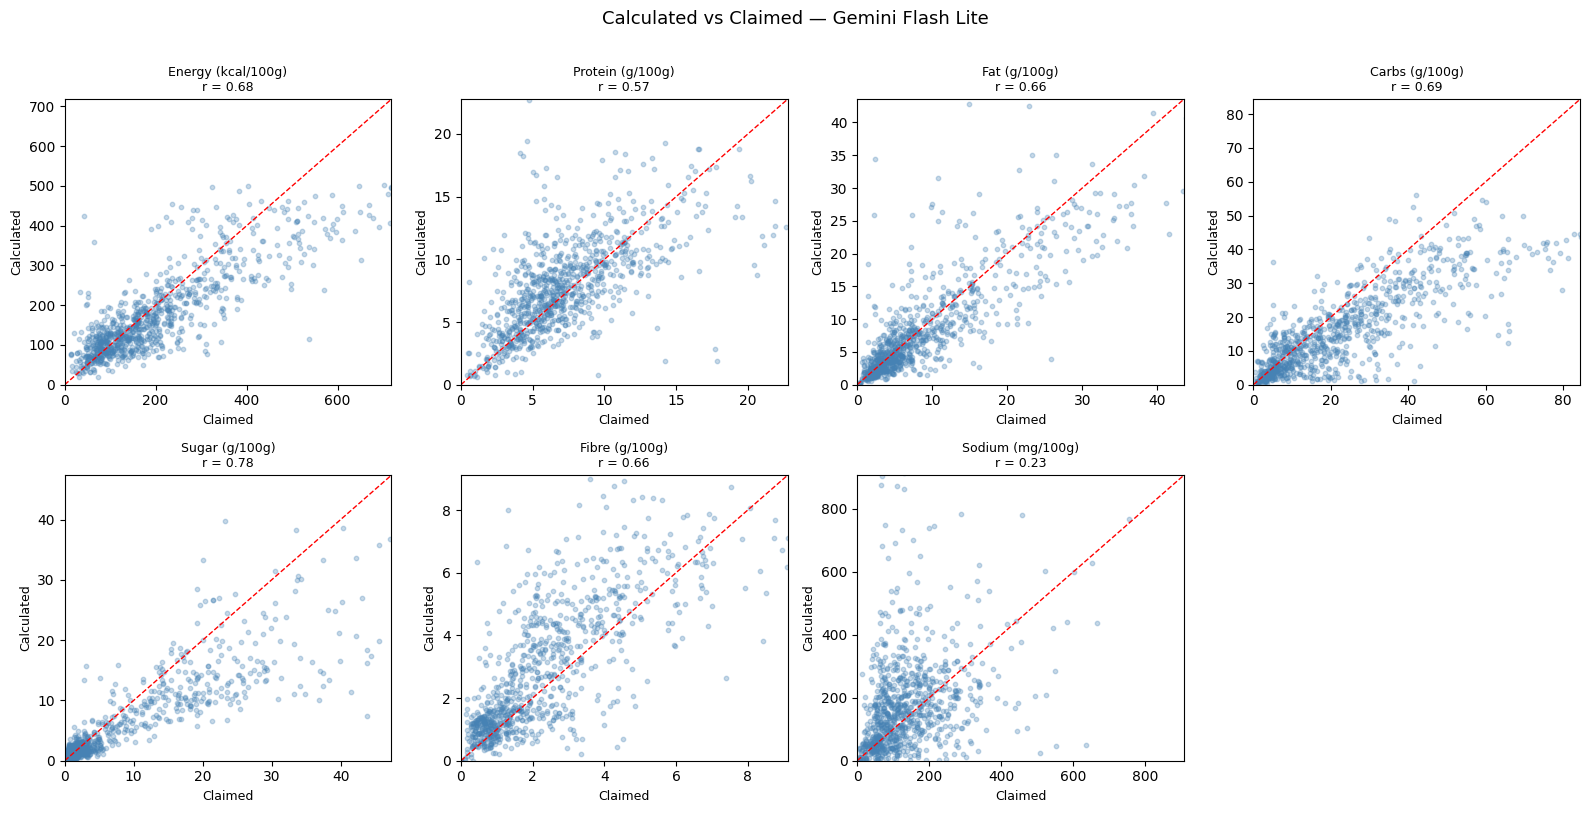

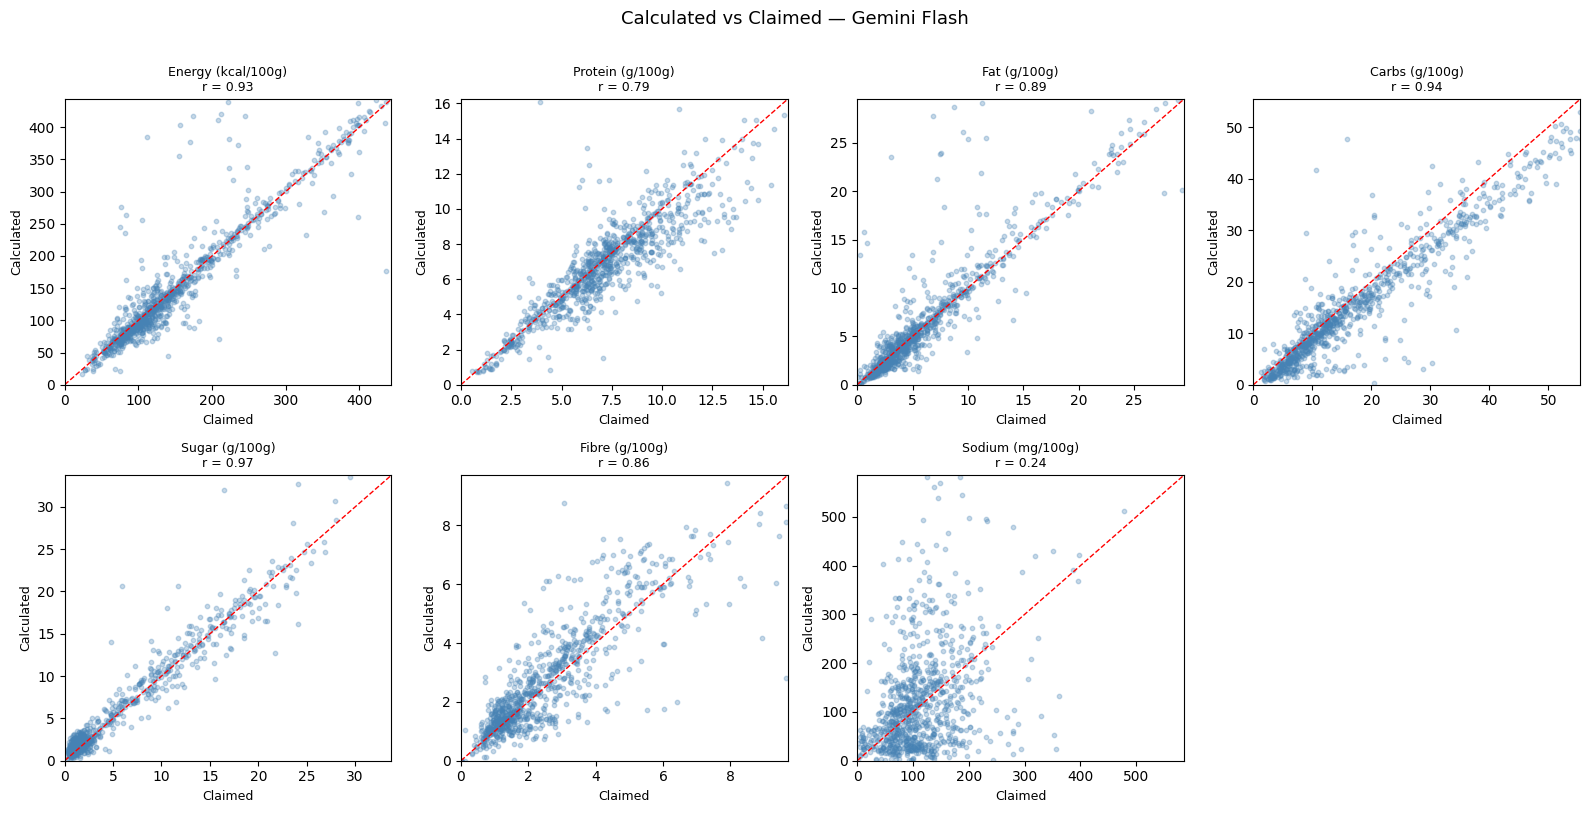

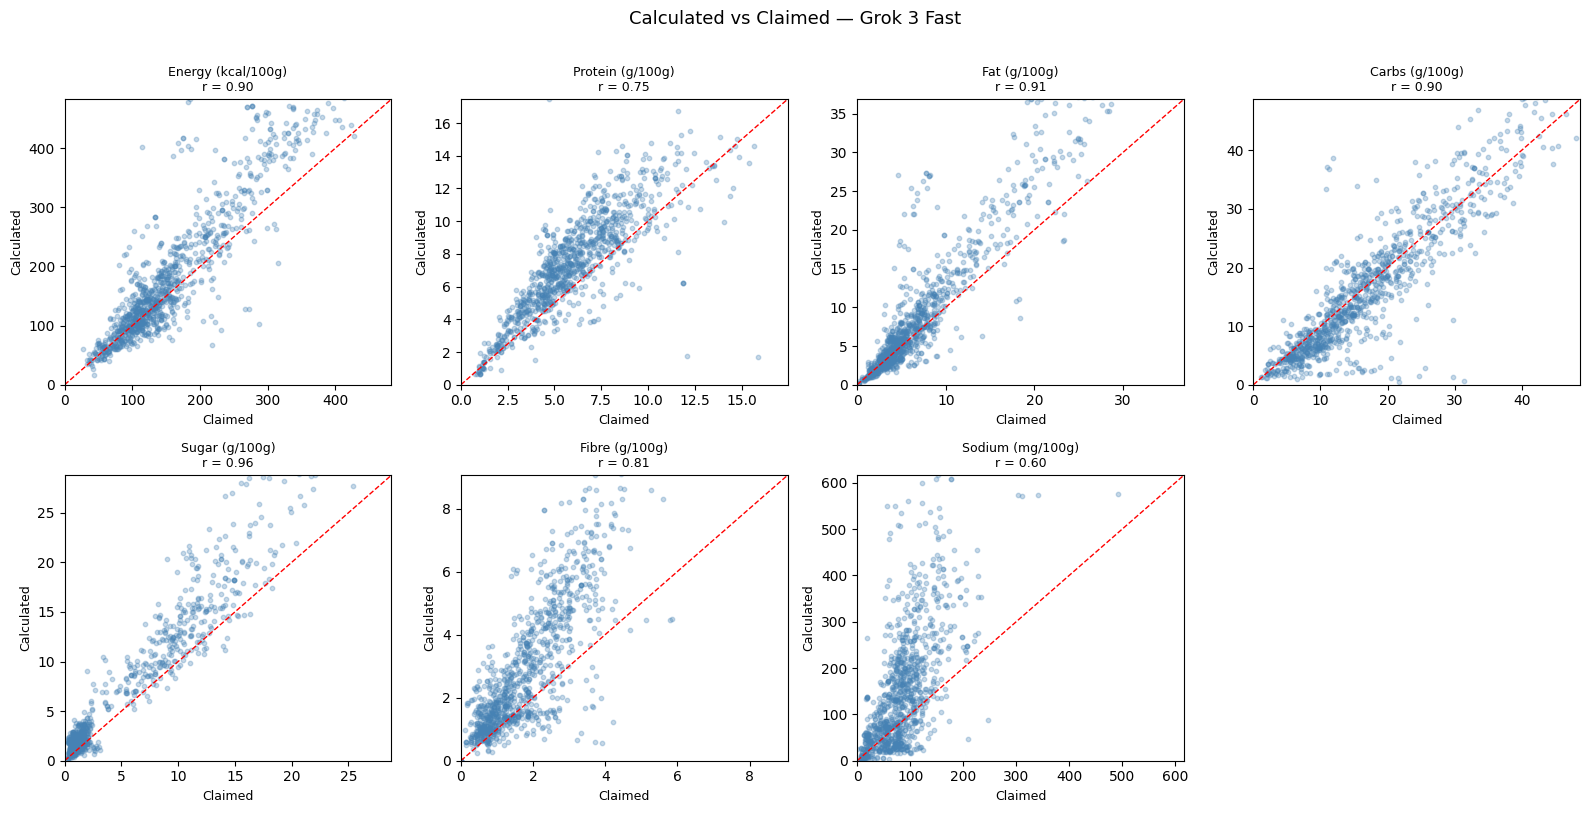

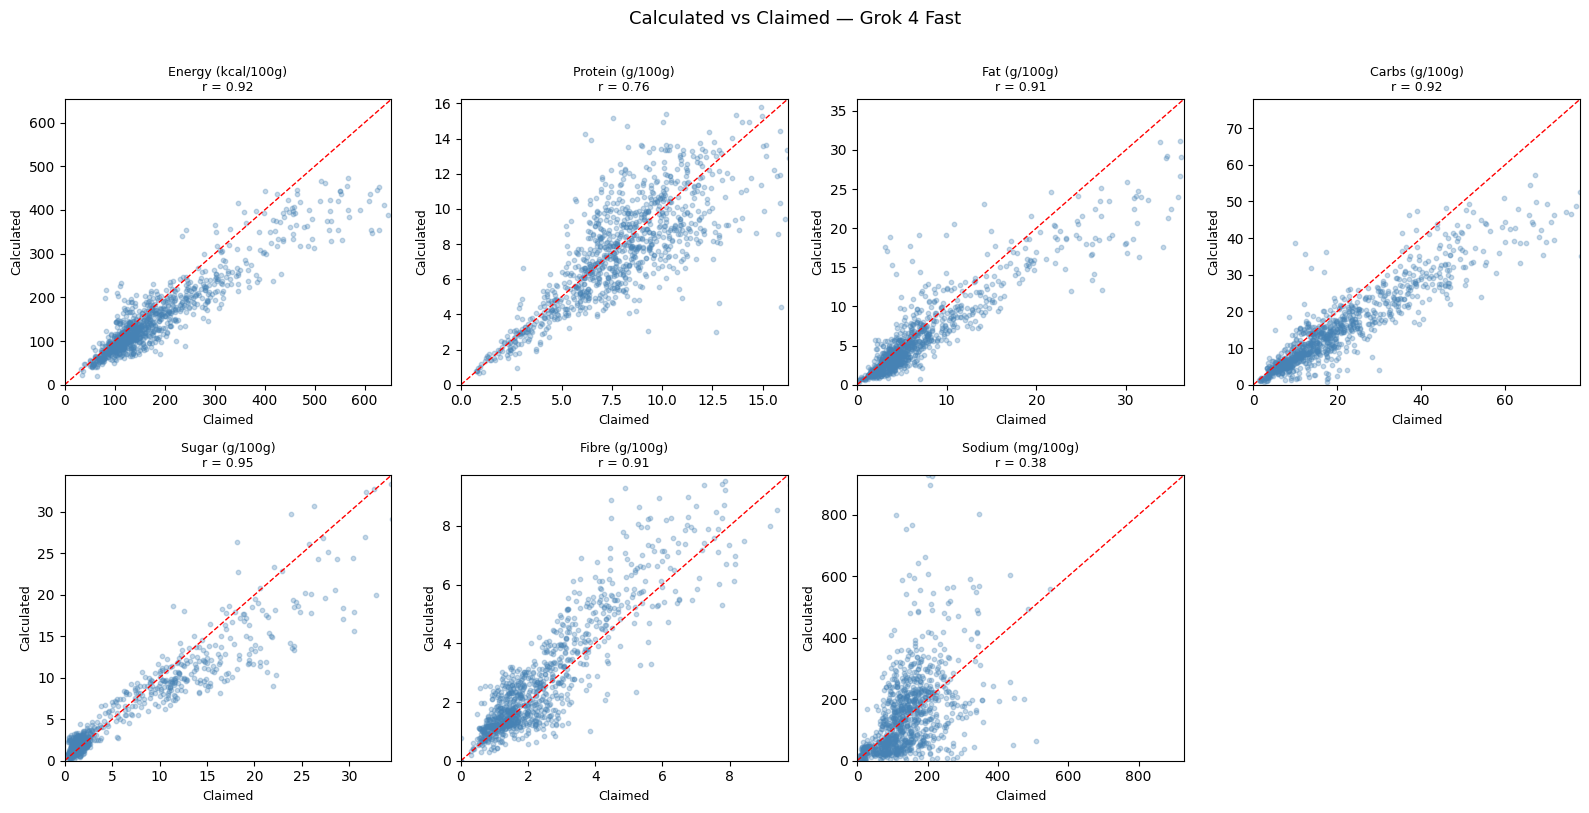

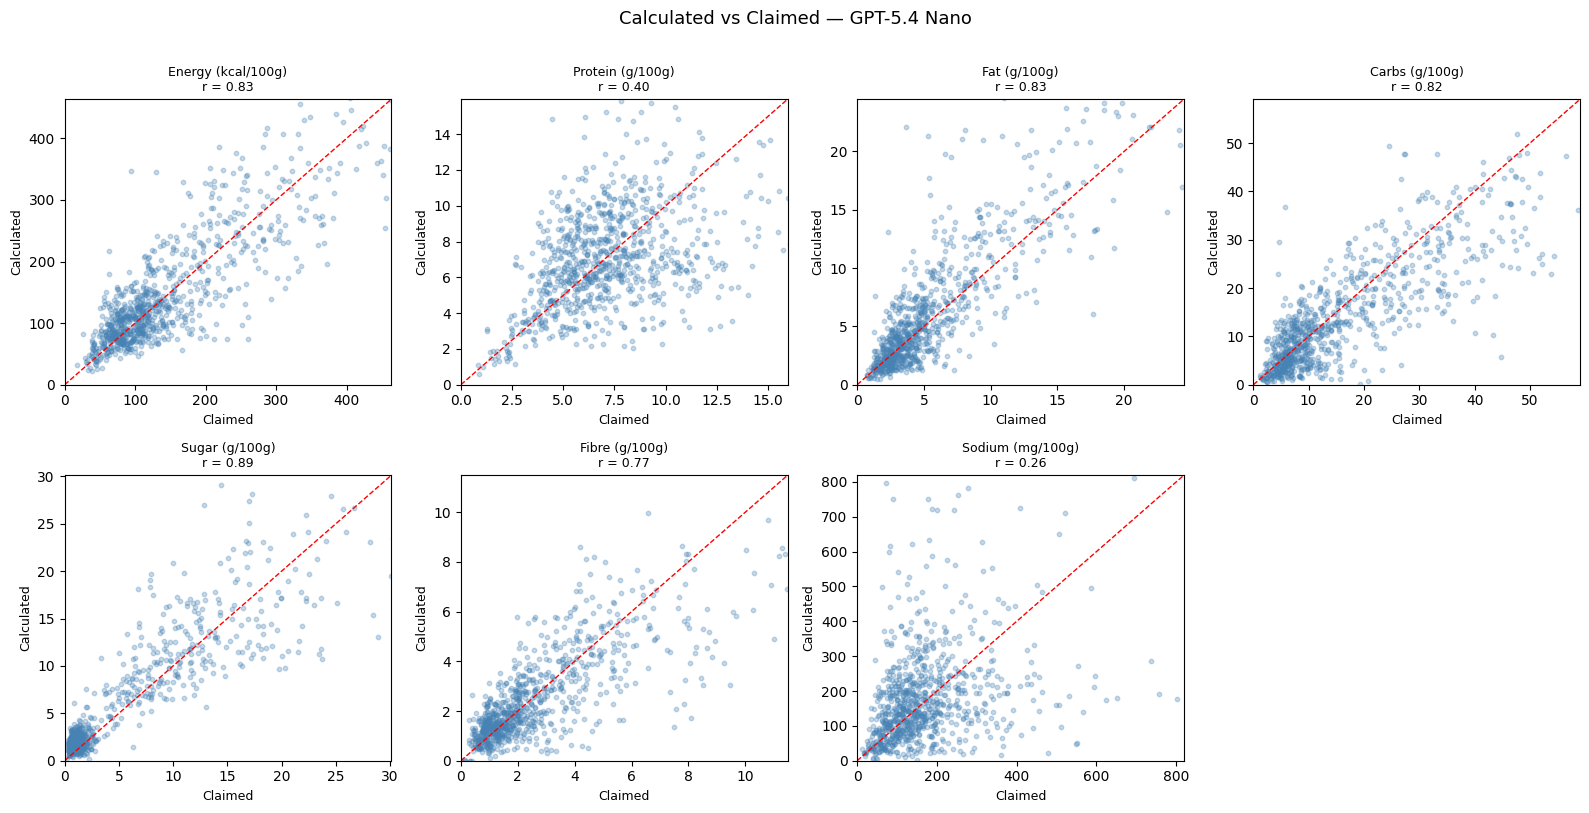

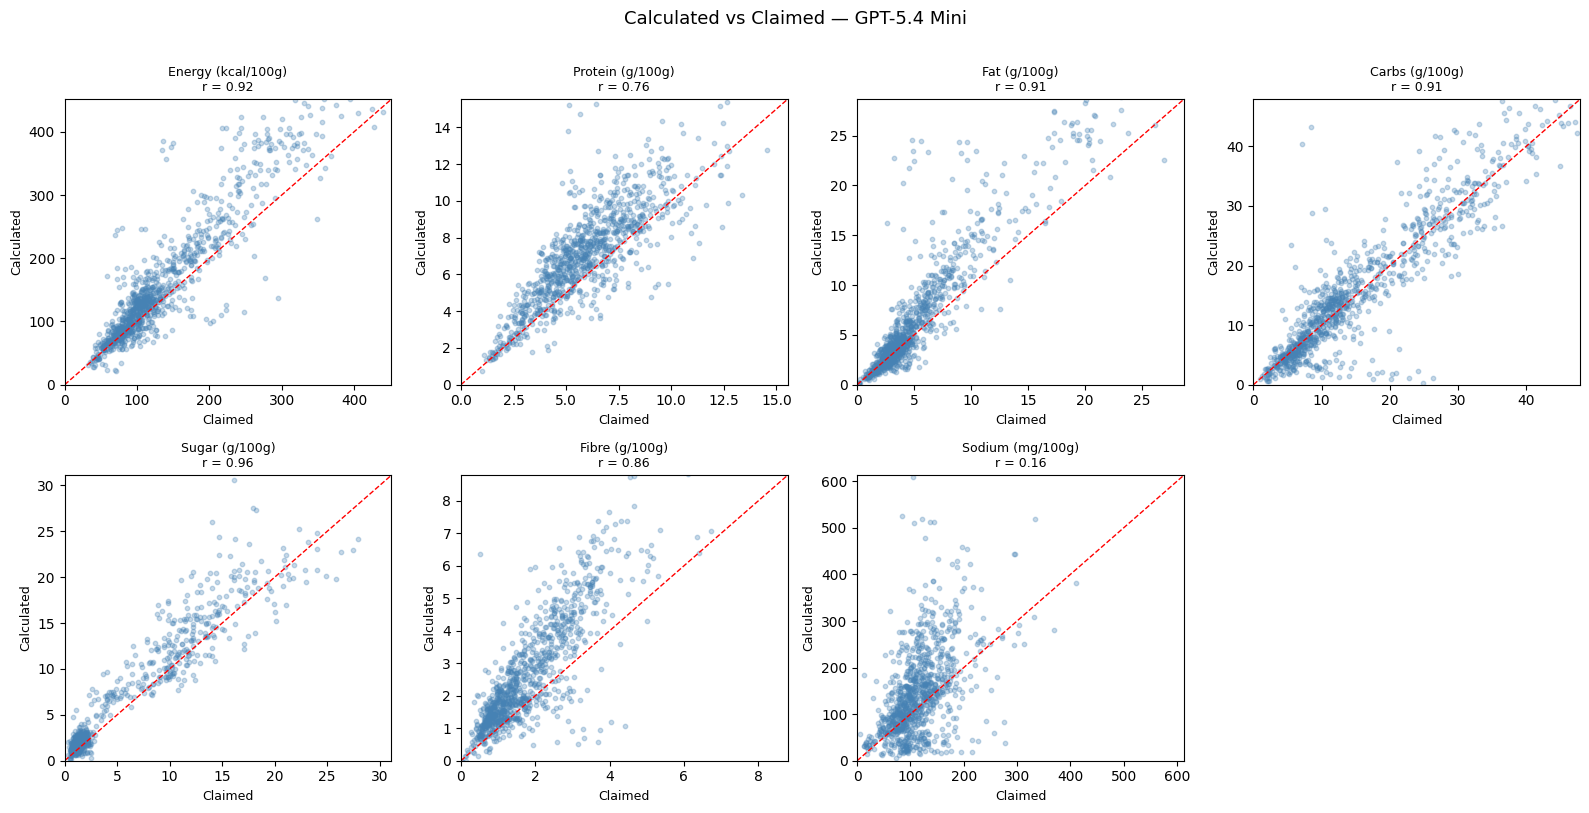

In [5]:
for model, path in files.items():
    df = pd.read_csv(path)
    w  = df["total_recipe_weight_g"].replace(0, np.nan)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, (label, calc_col, claim_col, unit) in enumerate(nutrients):
        ax   = axes[i]
        calc = df[calc_col] / w * 100
        if claim_col is None:
            claim = (df["claimed_salt_g"] / 2.5 * 1000) / w * 100
        else:
            claim = df[claim_col] / w * 100

        mask = calc.notna() & claim.notna()
        lim  = max(claim[mask].quantile(0.99), calc[mask].quantile(0.99))
        corr = calc[mask].corr(claim[mask])

        ax.scatter(claim[mask], calc[mask], alpha=0.3, s=10, color="steelblue")
        ax.plot([0, lim], [0, lim], "r--", lw=1)
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("Claimed", fontsize=9)
        ax.set_ylabel("Calculated", fontsize=9)
        ax.set_title(f"{label} ({unit}/100g)\nr = {corr:.2f}", fontsize=9)

    axes[7].set_visible(False)
    fig.suptitle(f"Calculated vs Claimed — {model}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 4. Sodium deep dive


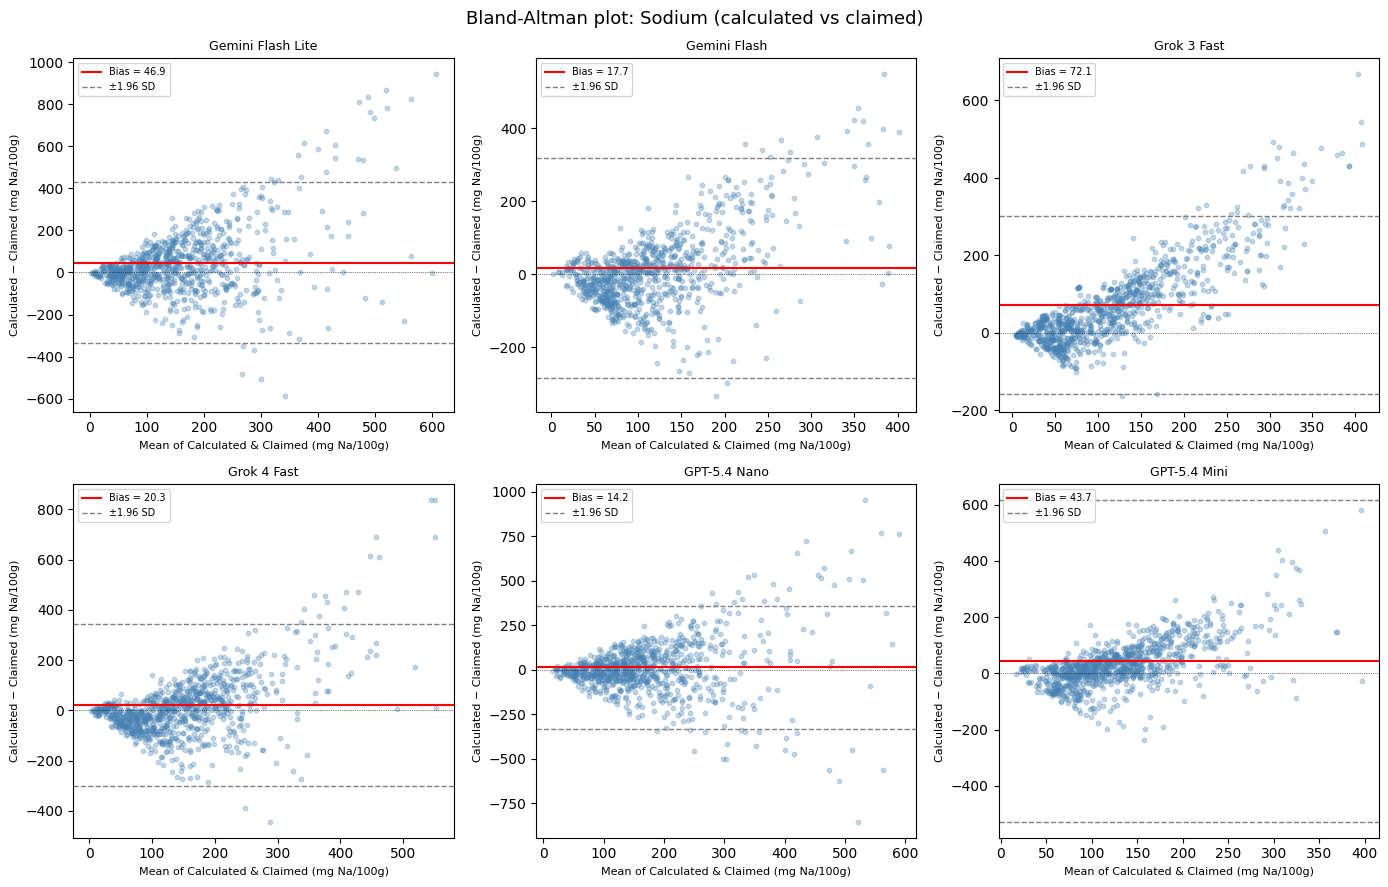

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (model, path) in enumerate(files.items()):
    df    = pd.read_csv(path)
    w     = df["total_recipe_weight_g"].replace(0, np.nan)
    calc  = df["calculated_sodium_(na)"]         / w * 100
    claim = (df["claimed_salt_g"] / 2.5 * 1000) / w * 100

    mask  = calc.notna() & claim.notna()
    avg   = (calc[mask] + claim[mask]) / 2
    diff  = calc[mask] - claim[mask]

    mean_diff = diff.mean()
    sd_diff   = diff.std()

    # clip for readability
    xlim = avg.quantile(0.99)
    plot_mask = avg < xlim

    ax = axes[i]
    ax.scatter(avg[plot_mask], diff[plot_mask], alpha=0.3, s=10, color="steelblue")
    ax.axhline(mean_diff,            color="red",    lw=1.5, label=f"Bias = {mean_diff:.1f}")
    ax.axhline(mean_diff + 1.96*sd_diff, color="gray", lw=1, linestyle="--", label="±1.96 SD")
    ax.axhline(mean_diff - 1.96*sd_diff, color="gray", lw=1, linestyle="--")
    ax.axhline(0, color="black", lw=0.5, linestyle=":")
    ax.set_xlabel("Mean of Calculated & Claimed (mg Na/100g)", fontsize=8)
    ax.set_ylabel("Calculated − Claimed (mg Na/100g)",         fontsize=8)
    ax.set_title(f"{model}", fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Bland-Altman plot: Sodium (calculated vs claimed)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/bland_altman_sodium.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Correlation heatmap — R² per model per nutrient

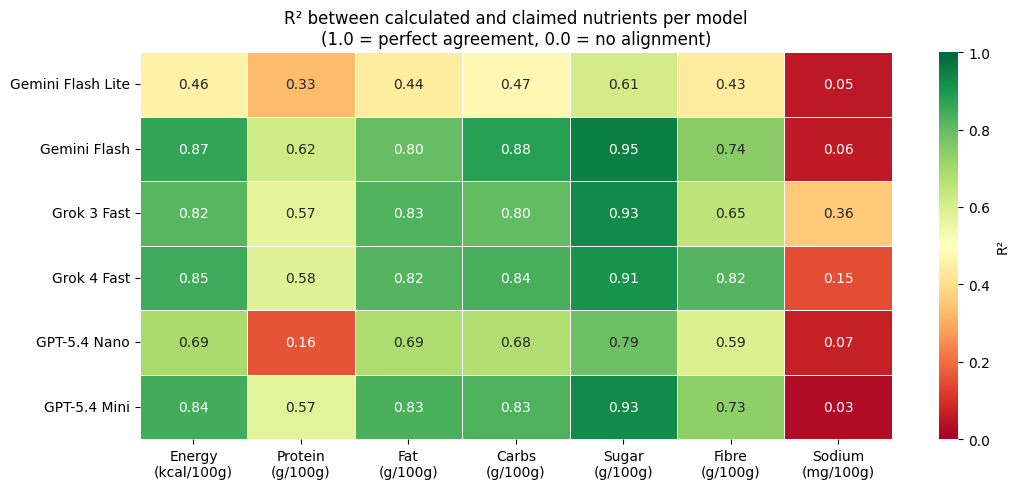

In [7]:
import seaborn as sns

nutrient_labels = [f"{n[0]}\n({n[3]}/100g)" for n in nutrients]

r2_matrix = []
for model, path in files.items():
    df = pd.read_csv(path)
    w  = df["total_recipe_weight_g"].replace(0, np.nan)
    row = []
    for label, calc_col, claim_col, unit in nutrients:
        calc = df[calc_col] / w * 100
        if claim_col is None:
            claim = (df["claimed_salt_g"] / 2.5 * 1000) / w * 100
        else:
            claim = df[claim_col] / w * 100
        mask = calc.notna() & claim.notna() & (calc > 0) & (claim > 0)
        r2 = calc[mask].corr(claim[mask]) ** 2
        row.append(round(r2, 3))
    r2_matrix.append(row)

r2_df = pd.DataFrame(r2_matrix, index=models, columns=nutrient_labels)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    r2_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "R²"}
)
ax.set_title("R² between calculated and claimed nutrients per model\n(1.0 = perfect agreement, 0.0 = no alignment)", fontsize=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figures/r2_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

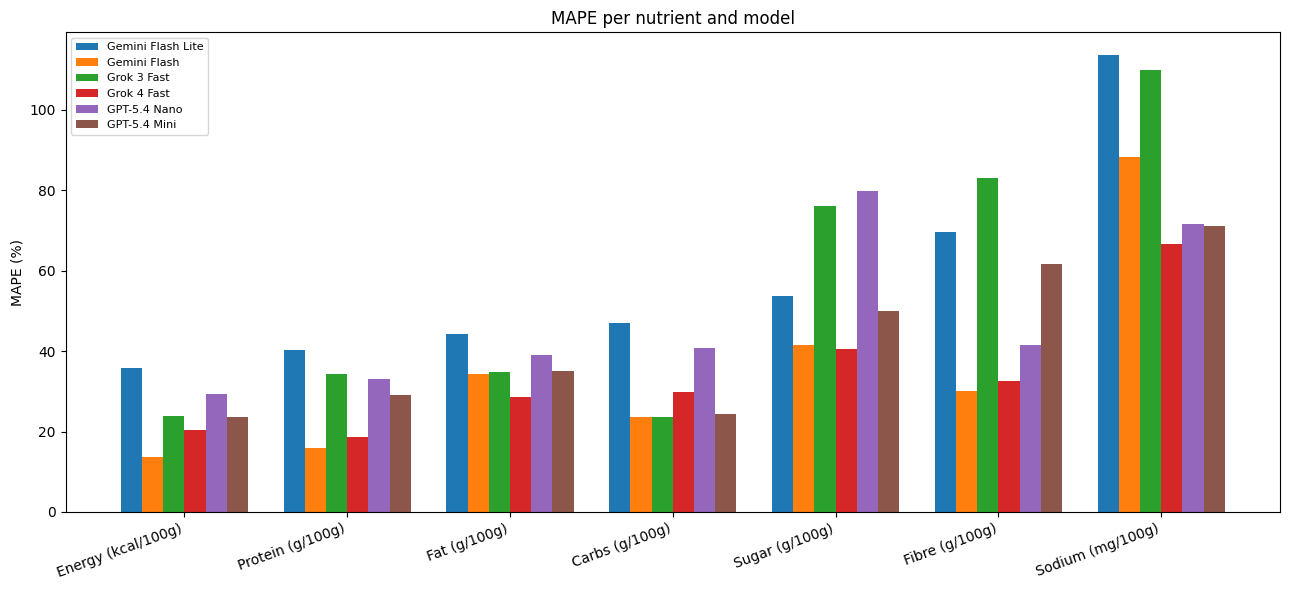

In [8]:
nutrient_labels = [f"{n[0]} ({n[3]}/100g)" for n in nutrients]
x = np.arange(len(nutrient_labels))
width = 0.13

fig, ax = plt.subplots(figsize=(13, 6))

for j, model in enumerate(models):
    mapes = [
        results_df.loc[(results_df["Model"] == model) & (results_df["Nutrient"] == f"{n[0]} ({n[3]}/100g)"), "MAPE (%)"].values[0]
        for n in nutrients
    ]
    ax.bar(x + j * width, mapes, width, label=model)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(nutrient_labels, rotation=20, ha="right")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE per nutrient and model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/mape_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Pairs plot — correlation matrix of key calculated variables.

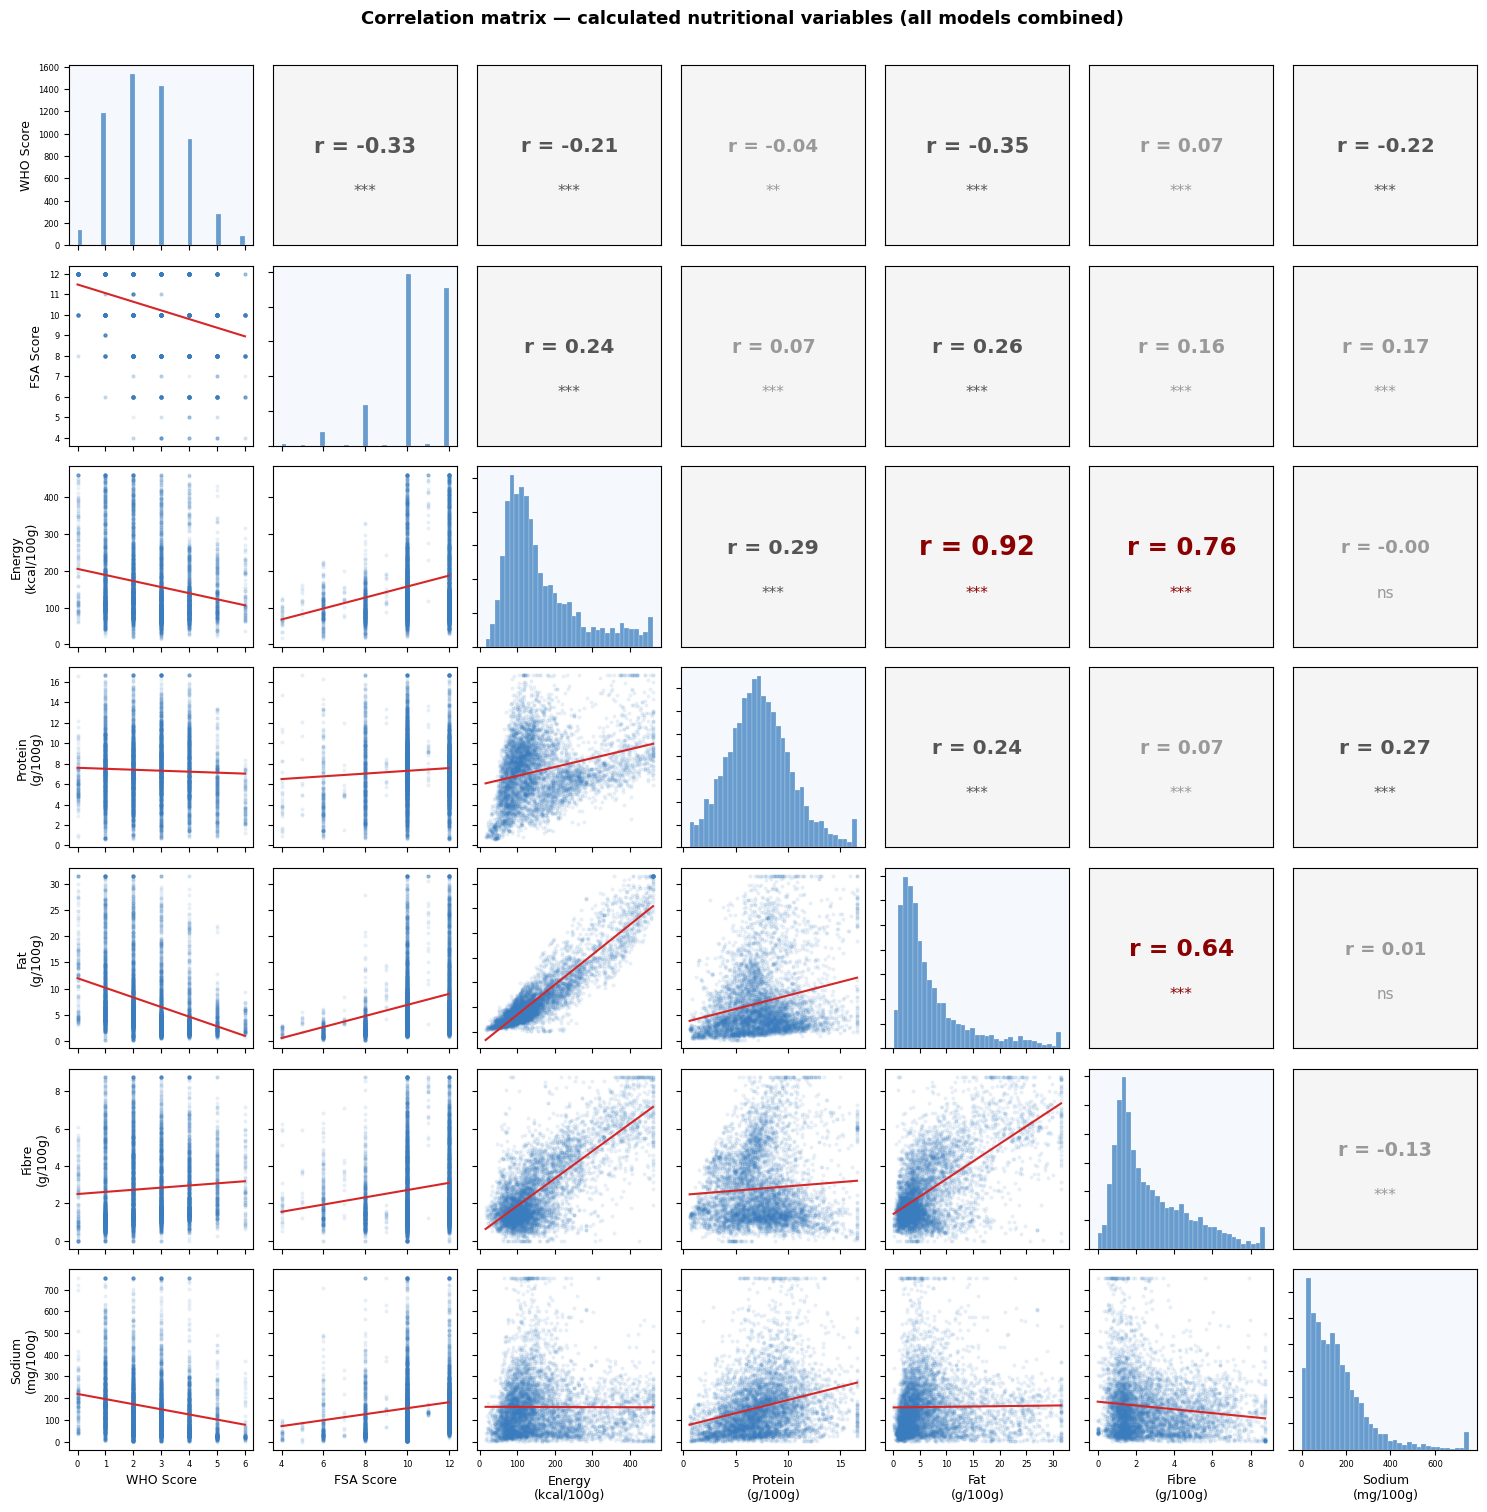

Saved: /Users/sanderborge/Library/CloudStorage/OneDrive-Personlig/Master/Matseroppgave/master_oppskrifter/notebooks/figures/pairs_plot.png

N = 5603 recipes

All pairwise Pearson r:
  WHO Score                 × FSA Score                  r=-0.329  p=1.528e-141
  WHO Score                 × Energy (kcal/100g)         r=-0.210  p=1.182e-56
  WHO Score                 × Protein (g/100g)           r=-0.040  p=3.022e-03
  WHO Score                 × Fat (g/100g)               r=-0.353  p=2.545e-164
  WHO Score                 × Fibre (g/100g)             r=+0.075  p=1.929e-08
  WHO Score                 × Sodium (mg/100g)           r=-0.223  p=3.357e-64
  FSA Score                 × Energy (kcal/100g)         r=+0.243  p=4.863e-76
  FSA Score                 × Protein (g/100g)           r=+0.072  p=7.347e-08
  FSA Score                 × Fat (g/100g)               r=+0.260  p=2.728e-87
  FSA Score                 × Fibre (g/100g)             r=+0.163  p=1.255e-34
  FSA Score               

In [9]:
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

dfs = [pd.read_csv(path) for path in files.values()]
all_df = pd.concat(dfs, ignore_index=True)
w = all_df["total_recipe_weight_g"]

pairs_df = pd.DataFrame({
    "WHO Score":          all_df["calculated_who_score"],
    "FSA Score":          all_df["calculated_fsa_score"],
    "Energy\n(kcal/100g)": all_df["calculated_calories.quantity"] / w * 100,
    "Protein\n(g/100g)":   all_df["calculated_protein"] / w * 100,
    "Fat\n(g/100g)":       all_df["calculated_fat"] / w * 100,
    "Fibre\n(g/100g)":     all_df["calculated_dietary_fibre"] / w * 100,
    "Sodium\n(mg/100g)":   all_df["calculated_sodium_(na)"] / w * 100,
}).dropna()

# Cap at 99th percentile so outliers don't compress the scatter plots.
for col in pairs_df.columns:
    pairs_df[col] = pairs_df[col].clip(upper=pairs_df[col].quantile(0.99))

cols = pairs_df.columns.tolist()
n = len(cols)

def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

fig, axes = plt.subplots(n, n, figsize=(15, 15))
fig.patch.set_facecolor('white')

SCATTER_COLOR = "#3a7dbf"
HIST_COLOR    = "#3a7dbf"
REG_COLOR     = "#d62728"

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        x = pairs_df.iloc[:, j]
        y = pairs_df.iloc[:, i]

        if i == j:
            ax.hist(x, bins=35, color=HIST_COLOR, alpha=0.75, edgecolor='white', linewidth=0.2)
            ax.set_facecolor('#f5f8fc')
        elif i > j:
            ax.scatter(x, y, alpha=0.08, s=4, color=SCATTER_COLOR, rasterized=True)
            m, b, r_val, p_val, _ = stats.linregress(x, y)
            xline = np.linspace(x.min(), x.max(), 200)
            ax.plot(xline, m * xline + b, color=REG_COLOR, linewidth=1.5)
        else:
            r_val, p_val = stats.pearsonr(x, y)
            stars = sig_stars(p_val)
            color = "#8B0000" if abs(r_val) > 0.4 else ("#555" if abs(r_val) > 0.2 else "#999")
            size  = 13 + 6 * abs(r_val)
            ax.text(0.5, 0.55, f"r = {r_val:.2f}", ha='center', va='center',
                    fontsize=size, fontweight='bold', color=color, transform=ax.transAxes)
            ax.text(0.5, 0.30, stars, ha='center', va='center',
                    fontsize=11, color=color, transform=ax.transAxes)
            ax.set_facecolor('#f5f5f5')
            ax.set_xticks([])
            ax.set_yticks([])

        if i == n - 1:
            ax.set_xlabel(cols[j], fontsize=9, labelpad=4)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(cols[i], fontsize=9, labelpad=4)
        else:
            ax.set_yticklabels([])

        ax.tick_params(labelsize=6)

plt.suptitle("Correlation matrix — calculated nutritional variables (all models combined)",
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(rect=[0, 0, 1, 1])

out_path = os.path.join(os.path.dirname(os.path.abspath("nutrient_comparison.ipynb")), "figures", "pairs_plot.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")
print(f"\nN = {len(pairs_df)} recipes")
print("\nAll pairwise Pearson r:")
for i in range(n):
    for j in range(i+1, n):
        r_val, p_val = stats.pearsonr(pairs_df.iloc[:, i], pairs_df.iloc[:, j])
        print(f"  {cols[i].replace(chr(10), ' '):25s} × {cols[j].replace(chr(10), ' '):25s}  r={r_val:+.3f}  p={p_val:.3e}")

---
## 7. Pairs plots — multiple views

Three pairs plots exploring different combinations:

- **7a. Calculated macro nutrients** — internal structure (how nutrients relate to each other)
- **7b. Claimed vs Calculated per nutrient** — AI accuracy (does the AI report the right values?)
- **7c. Recipe characteristics vs health scores** — does ingredient count / weight predict healthiness?

In [10]:
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

dfs = [pd.read_csv(path) for path in files.values()]
all_df = pd.concat(dfs, ignore_index=True)
w = all_df["total_recipe_weight_g"]

NOTEBOOK_DIR = os.path.dirname(os.path.abspath("nutrient_comparison.ipynb"))

def pairs_plot(df_vars, title, filename, figsize=(15, 15)):
    """Pairs plot: lower=scatter+reg, diagonal=hist, upper=r+stars."""
    df_vars = df_vars.dropna()
    for col in df_vars.columns:
        df_vars[col] = df_vars[col].clip(upper=df_vars[col].quantile(0.99))

    cols = df_vars.columns.tolist()
    n = len(cols)

    def sig_stars(p):
        if p < 0.001: return "***"
        elif p < 0.01: return "**"
        elif p < 0.05: return "*"
        else: return "ns"

    fig, axes = plt.subplots(n, n, figsize=figsize)
    fig.patch.set_facecolor('white')

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            x = df_vars.iloc[:, j]
            y = df_vars.iloc[:, i]

            if i == j:
                ax.hist(x, bins=35, color="#3a7dbf", alpha=0.75,
                        edgecolor='white', linewidth=0.2)
                ax.set_facecolor('#f5f8fc')
            elif i > j:
                ax.scatter(x, y, alpha=0.08, s=4, color="#3a7dbf", rasterized=True)
                m, b, r_val, p_val, _ = stats.linregress(x, y)
                xline = np.linspace(x.min(), x.max(), 200)
                ax.plot(xline, m * xline + b, color="#d62728", linewidth=1.5)
            else:
                r_val, p_val = stats.pearsonr(x, y)
                stars = sig_stars(p_val)
                color = "#8B0000" if abs(r_val) > 0.4 else ("#444" if abs(r_val) > 0.2 else "#aaa")
                size  = 12 + 6 * abs(r_val)
                ax.text(0.5, 0.55, f"r = {r_val:.2f}", ha='center', va='center',
                        fontsize=size, fontweight='bold', color=color,
                        transform=ax.transAxes)
                ax.text(0.5, 0.28, stars, ha='center', va='center',
                        fontsize=10, color=color, transform=ax.transAxes)
                ax.set_facecolor('#f5f5f5')
                ax.set_xticks([]); ax.set_yticks([])

            if i == n - 1:
                ax.set_xlabel(cols[j], fontsize=9, labelpad=4)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(cols[i], fontsize=9, labelpad=4)
            else:
                ax.set_yticklabels([])
            ax.tick_params(labelsize=6)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.005)
    plt.tight_layout()
    out = os.path.join(NOTEBOOK_DIR, "figures", filename)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}  (N={len(df_vars)})")

print("Helper function ready.")

Helper function ready.


### 8a. Calculated macro nutrients — internal structure


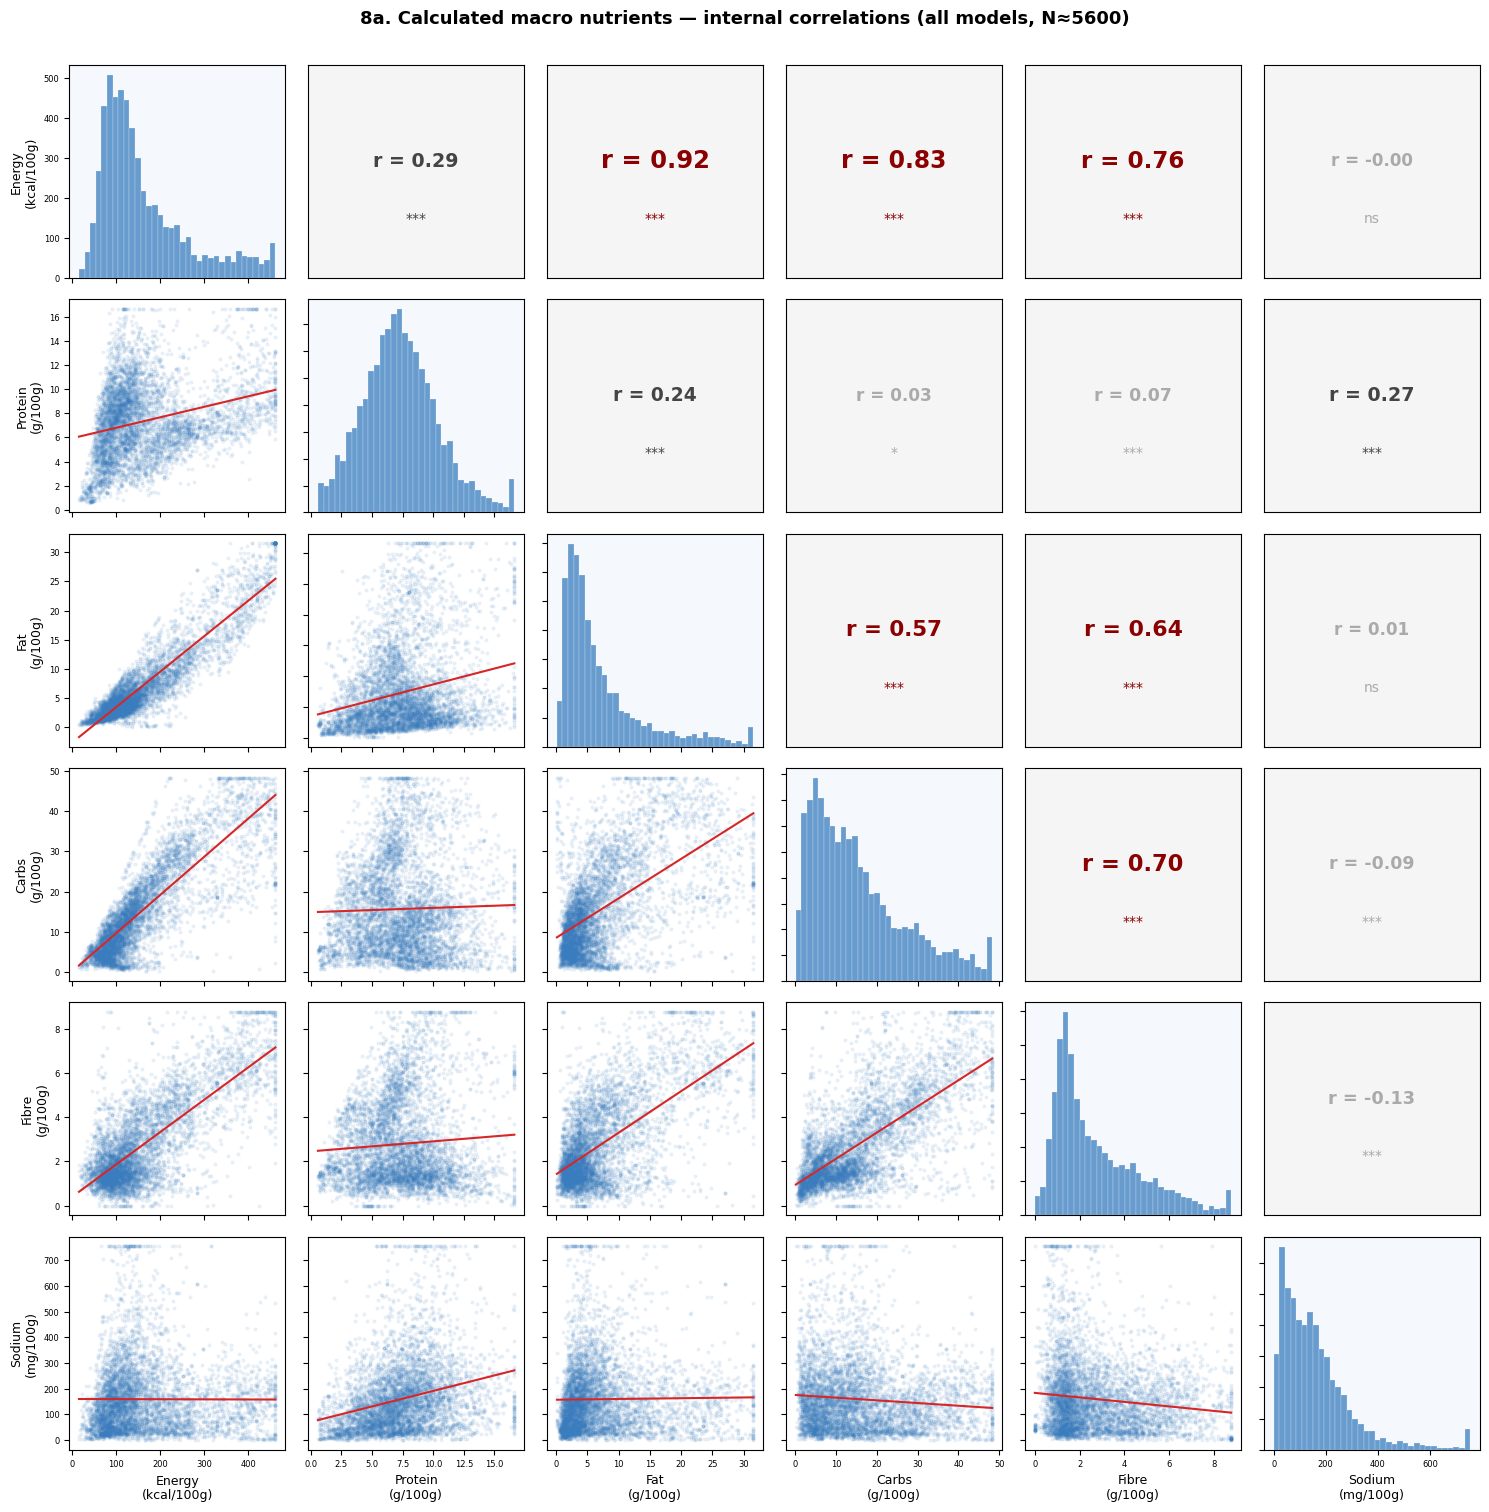

Saved: /Users/sanderborge/Library/CloudStorage/OneDrive-Personlig/Master/Matseroppgave/master_oppskrifter/notebooks/figures/pairs_macros.png  (N=5603)


In [11]:
macro_df = pd.DataFrame({
    "Energy\n(kcal/100g)":  all_df["calculated_calories.quantity"] / w * 100,
    "Protein\n(g/100g)":    all_df["calculated_protein"] / w * 100,
    "Fat\n(g/100g)":        all_df["calculated_fat"] / w * 100,
    "Carbs\n(g/100g)":      all_df["calculated_carbohydrate"] / w * 100,
    "Fibre\n(g/100g)":      all_df["calculated_dietary_fibre"] / w * 100,
    "Sodium\n(mg/100g)":    all_df["calculated_sodium_(na)"] / w * 100,
})

pairs_plot(
    macro_df,
    title="8a. Calculated macro nutrients — internal correlations (all models, N≈5600)",
    filename="pairs_macros.png",
)


### 8b. Claimed vs Calculated — AI accuracy

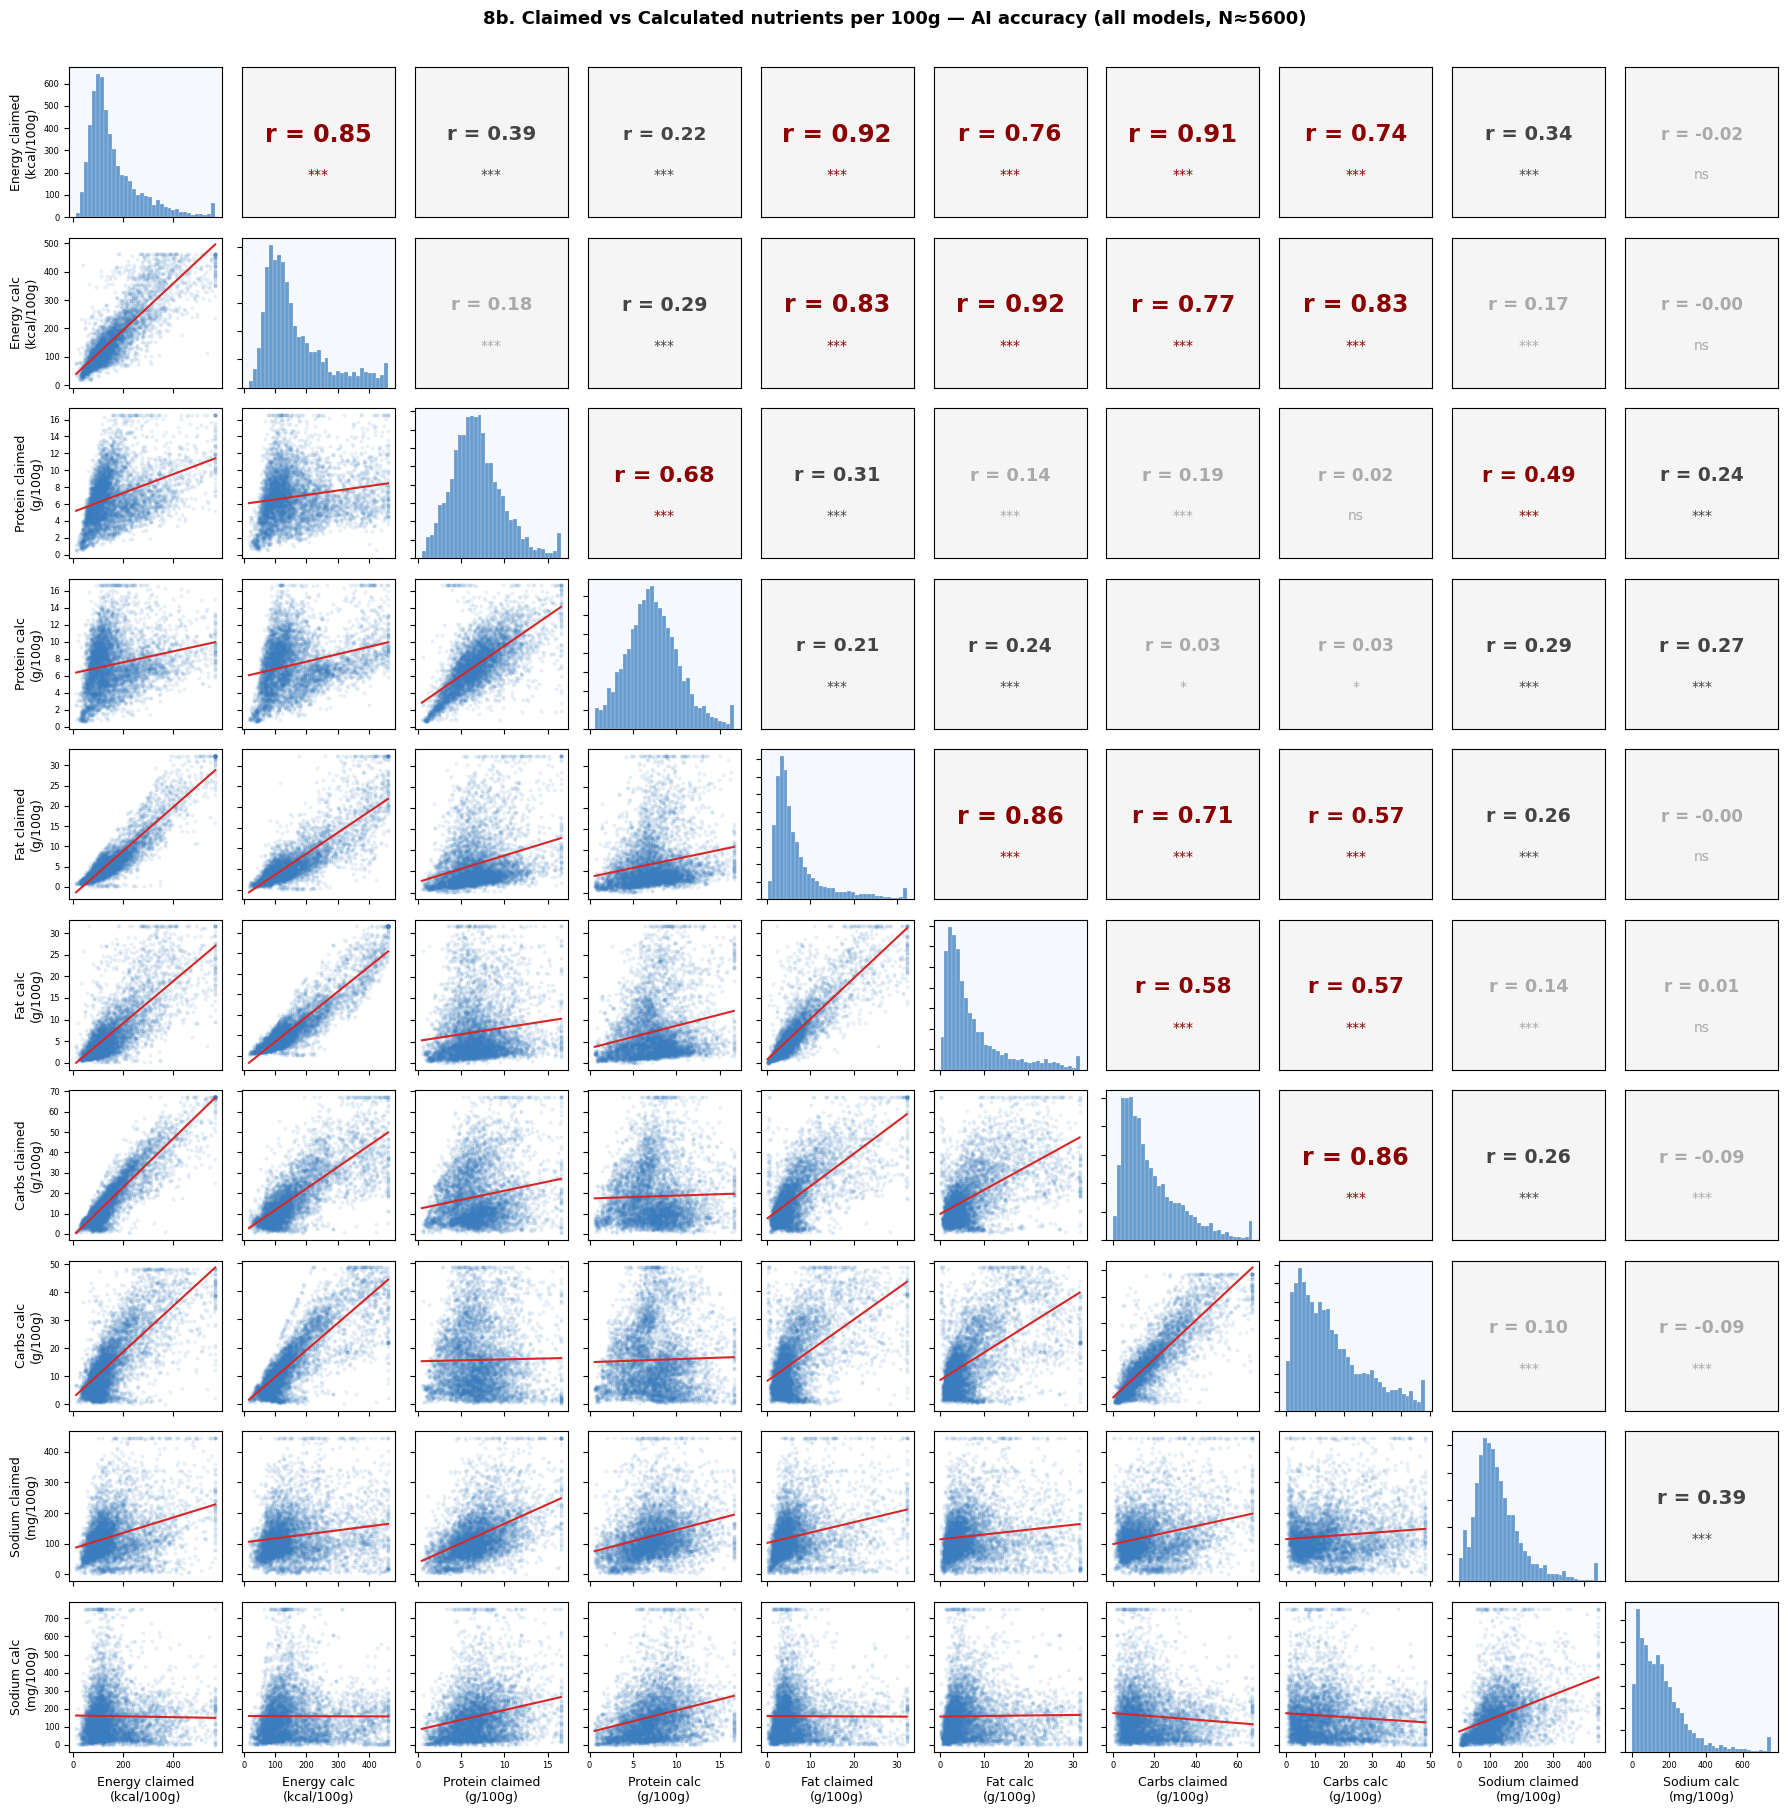

Saved: /Users/sanderborge/Library/CloudStorage/OneDrive-Personlig/Master/Matseroppgave/master_oppskrifter/notebooks/figures/pairs_claimed_vs_calc.png  (N=5603)


In [12]:
# Sodium: claimed is in salt_g → convert to mg; calculated is already mg
claimed_sodium_mg = (all_df["claimed_salt_g"] / 2.5) * 1000

acc_df = pd.DataFrame({
    "Energy claimed\n(kcal/100g)":   all_df["claimed_energy_kcal"] / w * 100,
    "Energy calc\n(kcal/100g)":      all_df["calculated_calories.quantity"] / w * 100,
    "Protein claimed\n(g/100g)":     all_df["claimed_protein_g"] / w * 100,
    "Protein calc\n(g/100g)":        all_df["calculated_protein"] / w * 100,
    "Fat claimed\n(g/100g)":         all_df["claimed_fat_g"] / w * 100,
    "Fat calc\n(g/100g)":            all_df["calculated_fat"] / w * 100,
    "Carbs claimed\n(g/100g)":       all_df["claimed_carbs_g"] / w * 100,
    "Carbs calc\n(g/100g)":          all_df["calculated_carbohydrate"] / w * 100,
    "Sodium claimed\n(mg/100g)":     claimed_sodium_mg / w * 100,
    "Sodium calc\n(mg/100g)":        all_df["calculated_sodium_(na)"] / w * 100,
})

pairs_plot(
    acc_df,
    title="8b. Claimed vs Calculated nutrients per 100g — AI accuracy (all models, N≈5600)",
    filename="pairs_claimed_vs_calc.png",
    figsize=(18, 18),
)


### 8c. Recipe characteristics vs health scores

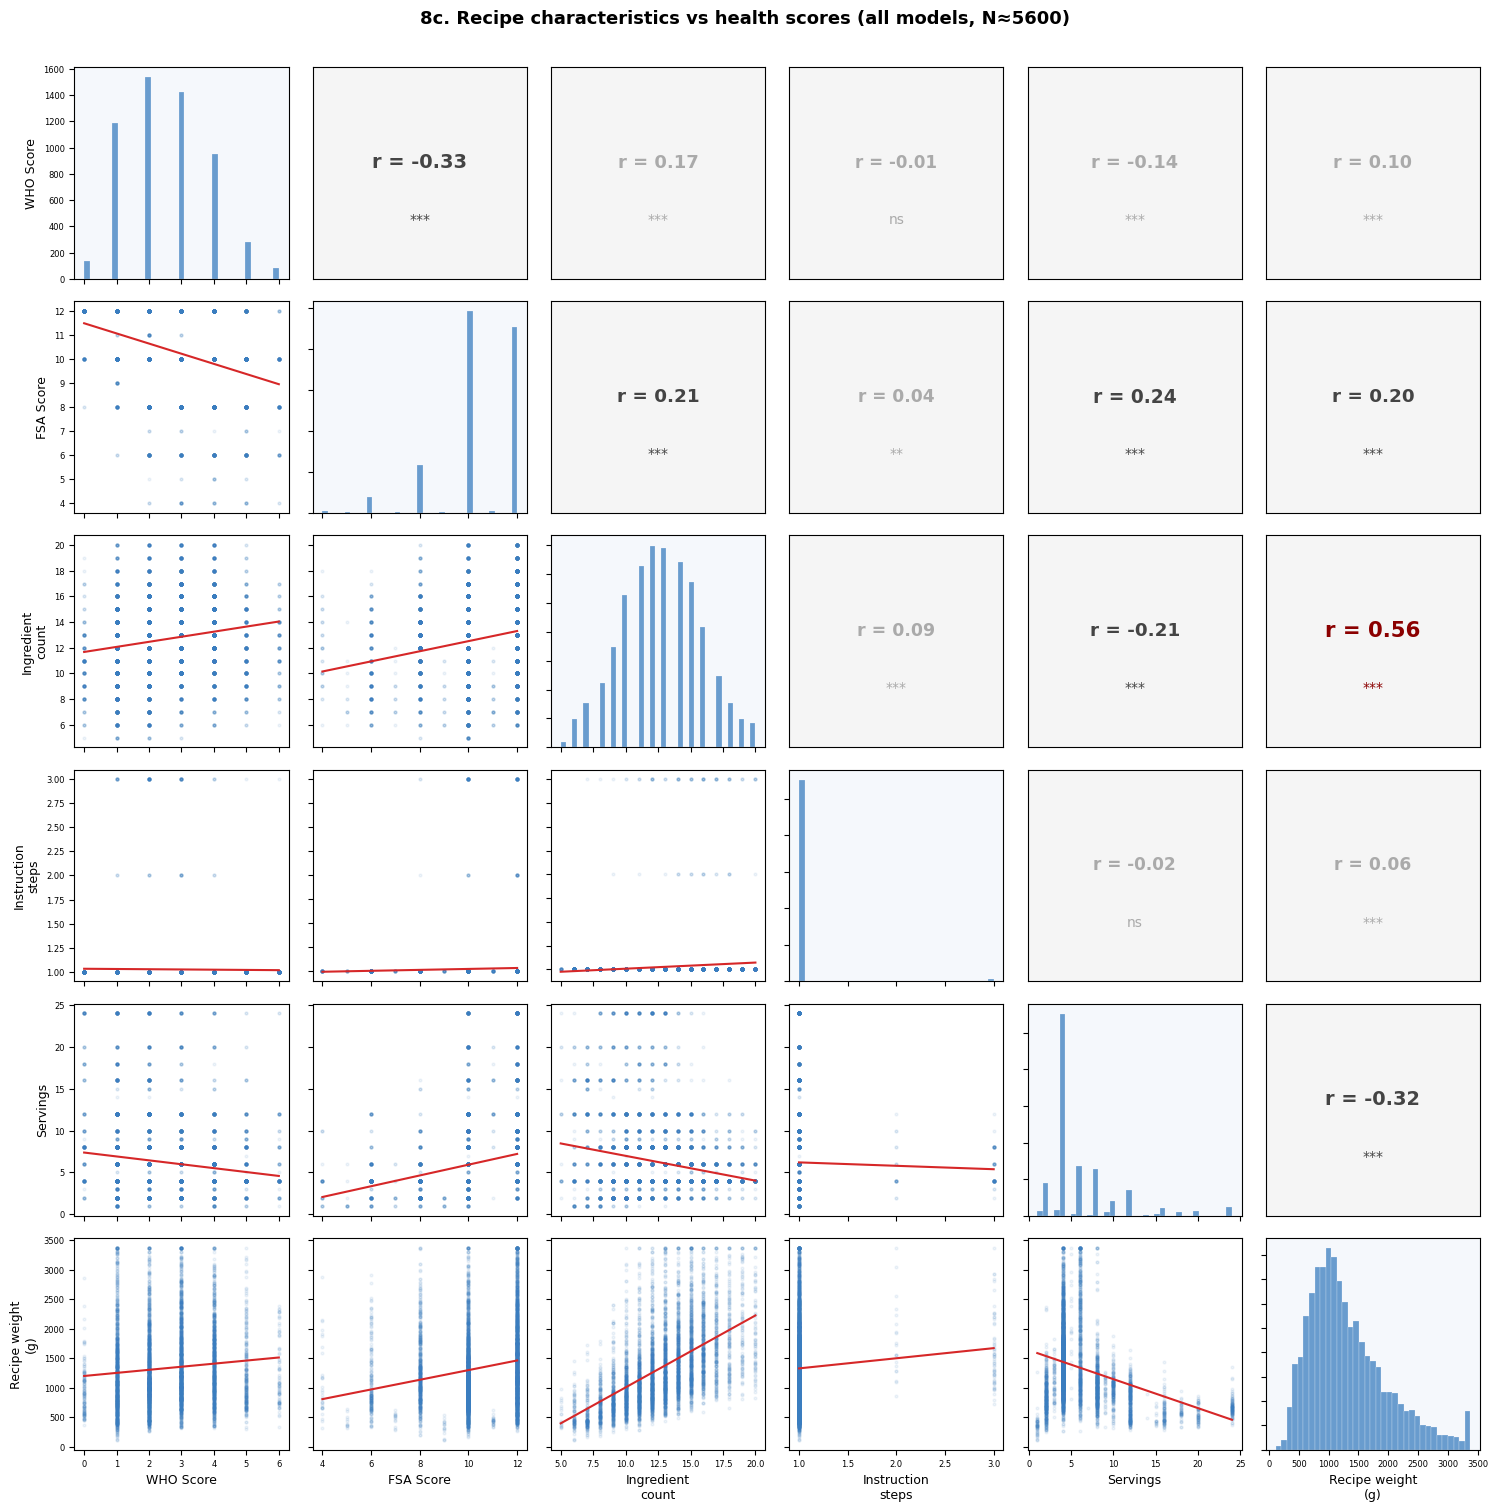

Saved: /Users/sanderborge/Library/CloudStorage/OneDrive-Personlig/Master/Matseroppgave/master_oppskrifter/notebooks/figures/pairs_recipe_characteristics.png  (N=5603)


In [13]:
import json

def count_ingredients(s):
    try:
        return len(json.loads(s))
    except Exception:
        return np.nan

def count_steps(s):
    # Instructions don't carry step delimiters, so non-blank lines are a proxy.
    if not isinstance(s, str):
        return np.nan
    return len([l for l in s.split('\n') if l.strip()])

n_ingredients = all_df["ingredients_json"].apply(count_ingredients)
n_steps       = all_df["instructions"].apply(count_steps)

char_df = pd.DataFrame({
    "WHO Score":          all_df["calculated_who_score"],
    "FSA Score":          all_df["calculated_fsa_score"],
    "Ingredient\ncount":  n_ingredients,
    "Instruction\nsteps": n_steps,
    "Servings":           pd.to_numeric(all_df["servings"], errors="coerce"),
    "Recipe weight\n(g)": w,
})

pairs_plot(
    char_df,
    title="8c. Recipe characteristics vs health scores (all models, N≈5600)",
    filename="pairs_recipe_characteristics.png",
)